# Win-Back Email Incrementality — Causal Analysis

## EDA

Load `data/customers.csv` and `data/panel.csv`. 

In [42]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from scipy import stats

In [43]:
df_customers = pd.read_csv("data/customers.csv")
df_panel = pd.read_csv("data/panel.csv")

In [20]:
df_customers.head()

,customer_id,latent_quality,frequency_pre,monetary_pre,recency_pre,p_floor,true_tau,propensity_true,treated,lapse_bucket
0,0,0.304717,2,88.16,67.3,0.002394,0.406131,0.406362,1,moderate
1,1,-1.039984,2,37.73,100.1,0.001144,0.209670,0.411858,1,moderate
2,2,0.750451,3,98.03,61.9,0.003057,0.438843,0.451131,0,moderate
3,3,0.940565,7,37.50,68.8,0.003393,0.397277,0.536649,0,moderate
4,4,-1.951035,1,20.78,119.8,0.000693,0.091073,0.396623,0,moderate


In [21]:
df_customers.groupby(['treated'])[['frequency_pre', 'monetary_pre', 'recency_pre']].mean()

,frequency_pre,monetary_pre,recency_pre
treated,,,
0,3.118092,59.149134,96.575625
1,3.995962,74.314264,111.813648


In [22]:
df_panel.head()

,customer_id,period,is_post,purchased,order_value
0,0,-12,0,0,0.0
1,1,-12,0,0,0.0
2,2,-12,0,0,0.0
3,3,-12,0,0,0.0
4,4,-12,0,0,0.0


In [23]:
df_customers.groupby('treated')['customer_id'].count()

treated
0    20484
1    24516
Name: customer_id, dtype: int64

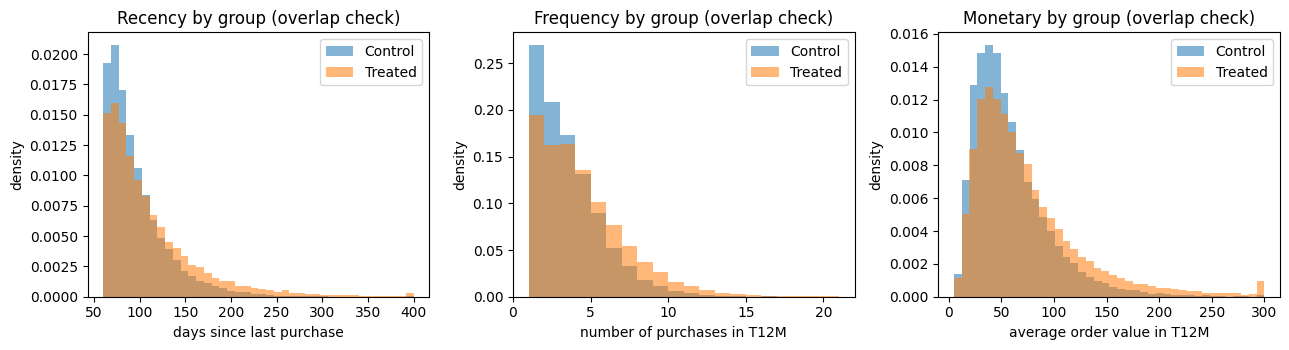

In [24]:
# check RFM distribution between treatment and control

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

for label, group in df_customers.groupby('treated'):
    name = 'Treated' if label == 1 else 'Control'
    axes[0].hist(group['recency_pre'].clip(upper=400), bins=40, alpha=0.55, label=name, density=True)
    axes[1].hist(group['frequency_pre'], bins=range(1,22), alpha=0.55, label=name, density=True)
    axes[2].hist(group['monetary_pre'].clip(upper=300), bins=40, alpha=0.55, label=name, density=True)

axes[0].set_title("Recency by group (overlap check)")
axes[0].set_xlabel("days since last purchase")
axes[1].set_title("Frequency by group (overlap check)")
axes[1].set_xlabel("number of purchases in T12M")
axes[2].set_title("Monetary by group (overlap check)")
axes[2].set_xlabel("average order value in T12M")

for ax in axes:
    ax.legend()
    ax.set_ylabel('density')

plt.tight_layout()
plt.show()

## 1. Naive Estimate

The number a marketing dashboard would show first: post-period reactivation rate, treated vs. control, with no adjustment for the pre-existing baseline gap. 

In [44]:
df_combine = df_panel.merge(df_customers[["customer_id", "treated"]], how="inner", on="customer_id")

# Collapse each customer's weekly rows down to one "did they purchase at least
# once" flag per pre/post window -- avoids the many-to-many merge problem
window = (
    df_combine.groupby(["customer_id", "treated", "is_post"])["purchased"]
    .max()
    .reset_index()
    .pivot(index=["customer_id", "treated"], columns="is_post", values="purchased")
    .reset_index()
)
window.columns = ["customer_id", "treated", "purchased_pre", "purchased_post"]

# Reactivated = didn't buy pre-period, did buy post-period
window["reactivated"] = (window["purchased_pre"] == 0) & (window["purchased_post"] == 1)

# Avg order value: mean $ among actual purchase events in the post period
post_purchases = df_combine[(df_combine["is_post"] == 1) & (df_combine["purchased"] == 1)]
avg_order_value = post_purchases.groupby("treated")["order_value"].mean().rename("avg_order_value")

summary = (
    window.groupby("treated")
    .agg(total_customers=("customer_id", "count"),
         conversion_rate=("purchased_post", "mean"),
         reactivation_rate=("reactivated", "mean"))
    .join(avg_order_value)
)

naive_lift = summary.loc[1, "conversion_rate"] - summary.loc[0, "conversion_rate"]
print(f"Naive lift (conversion rate, treated - control): {naive_lift*100:.2f}pp")
summary

Naive lift (conversion rate, treated - control): 2.88pp


,total_customers,conversion_rate,reactivation_rate,avg_order_value
treated,,,,
0,20484,0.073618,0.060096,70.089572
1,24516,0.102423,0.079907,91.118204


## 2. Covariate imbalance recap

Identify if there is any selection bias between treatment and control.

In [45]:
# we look at covariates in terms of RFM specifically
# calculate mean and t-statistic

COVARIATES = ['recency_pre', 'frequency_pre', 'monetary_pre']
res = []

for col in COVARIATES:
    treatment = df_customers.loc[df_customers['treated'] == 1, col]
    control = df_customers.loc[df_customers['treated'] == 0, col]
    t_stat, pval = stats.ttest_ind(treatment, control, equal_var=False)
    res.append(
        {
            'Covariate': col,
            'Control_mean': control.mean(),
            'Treatment_mean': treatment.mean(),
            'Diff': treatment.mean() - control.mean(),
            'T-statistic': t_stat
        }
    )

imbalance_table = pd.DataFrame(res).round(3)
imbalance_table


,Covariate,Control_mean,Treatment_mean,Diff,T-statistic
0,recency_pre,96.576,111.814,15.238,36.894
1,frequency_pre,3.118,3.996,0.878,37.693
2,monetary_pre,59.149,74.314,15.165,35.107


## 3. Parallel trends check

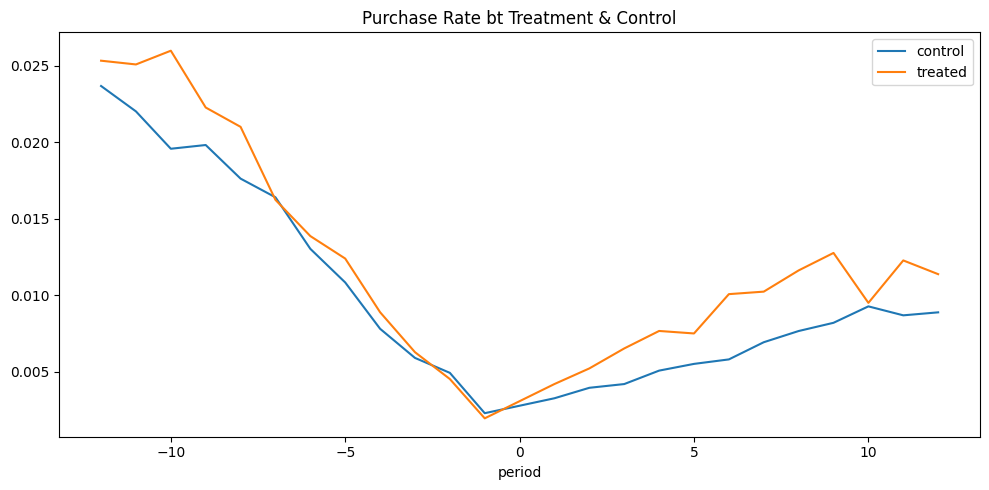

In [46]:
# weekly purchase rate

aggregate = (
    df_combine.groupby(['treated','period'])
    .agg(
        purchase_rt= ('purchased','mean'),
        avg_order_value= ('order_value', 'mean')
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10,5))

for label, group in aggregate.groupby('treated'):
    name = 'treated' if label == 1 else 'control'
    ax.plot(group['period'], group['purchase_rt'], label=name)

ax.set_title("Purchase Rate bt Treatment & Control")
ax.legend()
ax.set_xlabel('period')

plt.tight_layout()
plt.show()


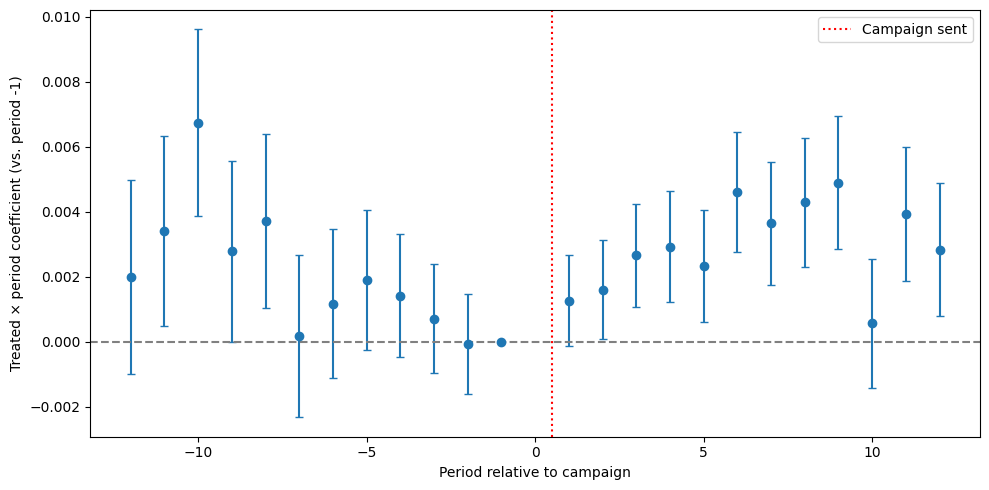

In [47]:
# Extension: event-study (leads and lags) regression

model = smf.ols(
    "purchased ~ treated * C(period, Treatment(reference=-1))",
    data=df_combine
).fit(cov_type="cluster", cov_kwds={"groups": df_combine["customer_id"]})

# Pull out just the treated:period interaction coefficients
event_coefs = model.params.filter(like="treated:C(period")
event_ci = model.conf_int().loc[event_coefs.index]

# Extract the actual period number from each coefficient's (fairly ugly) name
import re
periods = [int(re.search(r"\[T\.(-?\d+)\]", idx).group(1)) for idx in event_coefs.index]

event_study_df = pd.DataFrame({
    "period": periods,
    "coef": event_coefs.values,
    "ci_low": event_ci[0].values,
    "ci_high": event_ci[1].values,
}).sort_values("period")

# Add the reference period (-1) back in at coefficient 0, so the chart is continuous
ref_row = pd.DataFrame({"period": [-1], "coef": [0], "ci_low": [0], "ci_high": [0]})
event_study_df = pd.concat([event_study_df, ref_row]).sort_values("period").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(
    event_study_df["period"], event_study_df["coef"],
    yerr=[event_study_df["coef"] - event_study_df["ci_low"], event_study_df["ci_high"] - event_study_df["coef"]],
    fmt="o", capsize=3
)
ax.axhline(0, color="grey", linestyle="--")
ax.axvline(0.5, color="red", linestyle=":", label="Campaign sent")
ax.set_xlabel("Period relative to campaign")
ax.set_ylabel("Treated × period coefficient (vs. period -1)")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Plain DiD

Build the `Treated × Post` regression

In [48]:
# regress on purchased

df_window = (
    df_combine.groupby(["customer_id", "treated", "is_post"])["purchased"]
    .max()
    .reset_index()
)

model = smf.ols("purchased ~ treated * is_post", data=df_window).fit(
    cov_type="cluster", cov_kwds={"groups": df_window["customer_id"]}
)

did_estimate = model.params["treated:is_post"]
did_pvalue = model.pvalues["treated:is_post"]
did_ci = model.conf_int().loc["treated:is_post"]

print(f"DiD estimate (treated:is_post): {did_estimate*100:.3f}pp")
print(f"p-value: {did_pvalue:.4f}")
print(f"95% CI: [{did_ci[0]*100:.2f}pp, {did_ci[1]*100:.2f}pp]")

model.summary()

DiD estimate (treated:is_post): 1.288pp
p-value: 0.0025
95% CI: [0.45pp, 2.12pp]


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              purchased   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     407.0
Date:                Tue, 25 Aug 2026   Prob (F-statistic):          7.23e-261
Time:                        21:45:18   Log-Likelihood:                -27135.
No. Observations:               90000   AIC:                         5.428e+04
Df Residuals:                   89996   BIC:                         5.432e+04
Df Model:                           3                                         
Covariance Type:              cluster                                         
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.1492      0.002     59.931      0.000       0.144       0.154
treated             0.0159      0.003      4.633      0.000       0.009       0.023
is_post            -0.0756      0.003    -24.809      0.000      -0.082      -0.070
treated:is_post     0.0129      0.004      3.019      0.003       0.005       0.021
==============================================================================
Omnibus:                    36779.061   Durbin-Watson:                   1.963
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           112730.873
Skew:                           2.245   Prob(JB):                         0.00
Kurtosis:                       6.148   Cond. No.                         7.16
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

## 5. Placebo test — fake treatment date

Pick an arbitrary cutoff inside the pre-period, pretend that's when the campaign happened, and rerun DiD spec on data from before the real campaign. 

In [49]:
df_placebo_test = df_combine[df_combine['is_post'] == 0].copy()
df_placebo_test['is_post_new'] = np.where(df_placebo_test['period']>-8, 1, 0)

# customer-window scale, matching section 4: one row per customer per fake
# pre/post window, not a weekly purchase probability.
df_placebo_window = (
    df_placebo_test.groupby(['customer_id', 'treated', 'is_post_new'])['purchased']
    .max()
    .reset_index()
)

placebo_model = smf.ols("purchased ~ treated * is_post_new", data=df_placebo_window).fit(
    cov_type="cluster", cov_kwds={"groups": df_placebo_window['customer_id']}
)

placebo_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              purchased   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     209.0
Date:                Tue, 25 Aug 2026   Prob (F-statistic):          1.19e-134
Time:                        21:48:06   Log-Likelihood:                -11546.
No. Observations:               90000   AIC:                         2.310e+04
Df Residuals:                   89996   BIC:                         2.314e+04
Df Model:                           3                                         
Covariance Type:              cluster                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.0972      0.002     46.973      0.000       0.093       0.101
treated                 0.0150      0.003      5.207      0.000       0.009       0.021
is_post_new            -0.0380      0.003    -14.522      0.000      -0.043      -0.033
treated:is_post_new    -0.0122      0.004     -3.364      0.001      -0.019      -0.005
==============================================================================
Omnibus:                    52944.611   Durbin-Watson:                   1.977
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           318981.395
Skew:                           2.989   Prob(JB):                         0.00
Kurtosis:                      10.024   Cond. No.                         7.16
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

---

The placebo test (at two different cutoffs) and the event study both found a **non-trivial, systematic pre-period deviation** — not random scatter around zero, but a coherent pattern concentrated in the far pre-period (weeks −12 to −8), shrinking as you approach week −1. The placebo "effect" is comparable in magnitude to the real DiD estimate, which is too large to wave away.

**What this changes**: parallel trends is the assumption under suspicion, so the remaining sections are built to (a) respond to it directly with DiD variants, and (b) include at least one estimator that doesn't depend on it at all. Three DiD variants agreeing would *not* be meaningful triangulation — they'd share the very assumption in question. The regression-adjustment section below is the independence anchor. 

---

## 6. DiD with a shortened pre-period window

The event study localized the problem — the far pre-period is where the deviation lives. Restrict the pre-period to the weeks that looked cleanest (e.g. −6 to −1) and rerun the same DiD spec. 

In [50]:
df_combine_short = df_combine[df_combine['period'] > -8].copy()

# customer-window scale, matching sections 4 and 5: one row per customer per
# window, restricted to the shortened pre-period.
df_short_window = (
    df_combine_short.groupby(['customer_id', 'treated', 'is_post'])['purchased']
    .max()
    .reset_index()
)

model_trim = smf.ols("purchased ~ treated * is_post", data=df_short_window).fit(
    cov_type="cluster", cov_kwds={"groups": df_short_window['customer_id']}
)

trim_did_estimate = model_trim.params["treated:is_post"]
trim_did_pvalue = model_trim.pvalues["treated:is_post"]
trim_did_ci = model_trim.conf_int().loc["treated:is_post"]

print(f"did estimate: {trim_did_estimate*100:.2f} pp")
print(f"did estimate pvalue: {trim_did_pvalue:.6f}")
print(f"did estimate CI: [{trim_did_ci[0]*100:.2f} pp, {trim_did_ci[1]*100:.2f} pp]")

did estimate: 2.59 pp
did estimate pvalue: 0.000000
did estimate CI: [1.92 pp, 3.27 pp]


In [51]:
# placebo test

df_placebo_test_new = df_combine_short[df_combine_short['is_post'] == 0].copy()
df_placebo_test_new['is_post_new'] = np.where(df_placebo_test_new['period']>-4, 1, 0)

# customer-window scale, matching the other DiD/placebo cells above.
df_placebo_short_window = (
    df_placebo_test_new.groupby(['customer_id', 'treated', 'is_post_new'])['purchased']
    .max()
    .reset_index()
)

placebo_model_new = smf.ols("purchased ~ treated * is_post_new", data=df_placebo_short_window).fit(
    cov_type="cluster", cov_kwds={"groups": df_placebo_short_window['customer_id']}
)

placebo_did_estimate = placebo_model_new.params["treated:is_post_new"]
placebo_did_pvalue = placebo_model_new.pvalues["treated:is_post_new"]
placebo_did_ci = placebo_model_new.conf_int().loc["treated:is_post_new"]

print(f"did estimate: {placebo_did_estimate*100:.2f} pp")
print(f"did estimate pvalue: {placebo_did_pvalue:.6f}")
print(f"did estimate CI: [{placebo_did_ci[0]*100:.2f} pp, {placebo_did_ci[1]*100:.2f} pp]")

did estimate: -0.33 pp
did estimate pvalue: 0.151707
did estimate CI: [-0.78 pp, 0.12 pp]


## 7. PSM + DiD

Match treated and control customers on their RFM covariates *first*, then run the DiD spec on the matched sample only.

In [52]:
from sklearn.neighbors import NearestNeighbors

COVARIATES = ["recency_pre", "frequency_pre", "monetary_pre"]
SMD_THRESHOLD = 0.1     # conventional balance bar
CALIPER_MULT = 0.2      # caliper = 0.2 x SD of the propensity score


def _wmean(x, w):
    return np.average(x, weights=w)


def _wvar(x, w):
    return np.average((x - _wmean(x, w)) ** 2, weights=w)


def balance_report(customers, weight_col=None):
    """Weighted standardized mean difference per covariate.

    Weights matter here: matching is done WITH replacement, so a control
    reused k times represents k units of the matched sample. Computing SMDs
    on the distinct customers (weight 1 each) would describe a sample that
    doesn't exist.
    """
    w = customers[weight_col] if weight_col else pd.Series(1.0, index=customers.index)
    t_mask = customers["treated"] == 1

    rows = []
    for col in COVARIATES:
        tx, tw = customers.loc[t_mask, col], w[t_mask]
        cx, cw = customers.loc[~t_mask, col], w[~t_mask]
        pooled_sd = np.sqrt((_wvar(tx, tw) + _wvar(cx, cw)) / 2)
        d = (_wmean(tx, tw) - _wmean(cx, cw)) / pooled_sd
        rows.append({"covariate": col, "smd": d, "balanced": abs(d) < SMD_THRESHOLD})
    return pd.DataFrame(rows)


def fit_and_match(formula, customers):
    """Estimate the propensity score from `formula`, then caliper-match on it.

    Matching is with replacement (the treated group is larger than control),
    so reused controls carry proportional weight in the outcome regression.
    """
    ps_model = smf.logit(formula, data=customers).fit(disp=0)

    customers = customers.copy()
    customers["pscore_est"] = ps_model.predict(customers)

    treated = customers[customers["treated"] == 1]
    control = customers[customers["treated"] == 0]
    caliper = CALIPER_MULT * customers["pscore_est"].std()

    nn = NearestNeighbors(n_neighbors=1).fit(control[["pscore_est"]])
    dist, idx = nn.kneighbors(treated[["pscore_est"]])
    keep = dist[:, 0] <= caliper

    matched_treated_ids = treated.loc[keep, "customer_id"].values
    matched_control_ids = control.iloc[idx[keep, 0]]["customer_id"].values

    control_counts = pd.Series(matched_control_ids).value_counts()
    weight_map = pd.concat([
        pd.Series(1.0, index=matched_treated_ids),
        control_counts.astype(float),
    ])

    matched = customers[customers["customer_id"].isin(weight_map.index)].copy()
    matched["w"] = matched["customer_id"].map(weight_map)

    diagnostics = {
        "match_rate": keep.mean(),
        "n_matched_treated": int(keep.sum()),
        "n_distinct_controls": control_counts.size,
    }
    return matched, weight_map, diagnostics


# --- Candidate propensity specifications, simplest first -------------------
# Standard PSM practice: iterate on the propensity model until covariates
# balance. This is legitimate *because it never looks at the outcome* --
# the only thing steering the choice is covariate balance, so there is no
# way to shop for a specification that produces a preferred effect estimate.

SPECIFICATIONS = [
    ("linear terms",
     "treated ~ recency_pre + frequency_pre + monetary_pre"),

    ("+ squared terms",
     "treated ~ recency_pre + frequency_pre + monetary_pre"
     " + I(recency_pre**2) + I(frequency_pre**2) + I(monetary_pre**2)"),

    ("+ interactions",
     "treated ~ recency_pre * frequency_pre * monetary_pre"
     " + I(recency_pre**2) + I(frequency_pre**2) + I(monetary_pre**2)"),
]

print("=== Balance BEFORE matching (full sample) ===")
print(balance_report(df_customers).round(3).to_string(index=False))

chosen_spec = None
for label, spec in SPECIFICATIONS:
    matched, weight_map, diag = fit_and_match(spec, df_customers)
    bal = balance_report(matched, weight_col="w")

    print(f"\n=== Spec: {label} ===")
    print(f"matched {diag['n_matched_treated']:,} treated "
          f"({diag['match_rate']:.1%} within caliper), "
          f"{diag['n_distinct_controls']:,} distinct controls used")
    print(bal.round(3).to_string(index=False))

    if bal["balanced"].all():
        chosen_spec = label
        print(f"\n--> All covariates balanced (|SMD| < {SMD_THRESHOLD}). "
              f"No higher-order terms needed; stopping here.")
        break
else:
    chosen_spec = SPECIFICATIONS[-1][0]
    print(f"\n--> No specification achieved full balance; "
          f"proceeding with the richest ('{chosen_spec}') and noting this as a limitation.")


=== Balance BEFORE matching (full sample) ===
    covariate   smd  balanced
  recency_pre 0.343     False
frequency_pre 0.353     False
 monetary_pre 0.327     False

=== Spec: linear terms ===
matched 24,516 treated (100.0% within caliper), 11,185 distinct controls used
    covariate    smd  balanced
  recency_pre -0.021      True
frequency_pre  0.013      True
 monetary_pre  0.020      True

--> All covariates balanced (|SMD| < 0.1). No higher-order terms needed; stopping here.


In [53]:
# --- DiD on the matched sample (using `weight_map` from the chosen spec above) ---
# customer-window scale, matching sections 4-6: one row per customer per
# window. Weight is constant per customer, so it survives the collapse via
# 'first'.

df_matched = df_combine[df_combine["customer_id"].isin(weight_map.index)].copy()
df_matched["w"] = df_matched["customer_id"].map(weight_map)

df_matched_window = (
    df_matched.groupby(["customer_id", "treated", "is_post"])
    .agg(purchased=("purchased", "max"), w=("w", "first"))
    .reset_index()
)

model_psm = smf.wls(
    "purchased ~ treated * is_post", data=df_matched_window, weights=df_matched_window["w"]
).fit(cov_type="cluster", cov_kwds={"groups": df_matched_window["customer_id"]})

psm_estimate = model_psm.params["treated:is_post"]
psm_pvalue = model_psm.pvalues["treated:is_post"]
psm_ci = model_psm.conf_int().loc["treated:is_post"]

print(f"PSM + DiD estimate (spec: {chosen_spec}): {psm_estimate*100:.2f}pp")
print(f"p-value: {psm_pvalue:.4f}")
print(f"95% CI: [{psm_ci[0]*100:.2f}pp, {psm_ci[1]*100:.2f}pp]")


# --- The real diagnostic: did matching shrink the pre-trend problem? ---
# If the curvature/composition story is right, equalising baseline RFM should
# reduce the spurious pre-period "effect". If the placebo deviation survives
# matching, composition was NOT the cause -- which is equally informative.

df_placebo_matched = df_matched[df_matched["is_post"] == 0].copy()
df_placebo_matched["is_post_new"] = (df_placebo_matched["period"] > -8).astype(int)

df_placebo_matched_window = (
    df_placebo_matched.groupby(["customer_id", "treated", "is_post_new"])
    .agg(purchased=("purchased", "max"), w=("w", "first"))
    .reset_index()
)

placebo_matched = smf.wls(
    "purchased ~ treated * is_post_new",
    data=df_placebo_matched_window,
    weights=df_placebo_matched_window["w"],
).fit(cov_type="cluster", cov_kwds={"groups": df_placebo_matched_window["customer_id"]})

pm_est = placebo_matched.params["treated:is_post_new"]
pm_p = placebo_matched.pvalues["treated:is_post_new"]

print(f"\n--- Placebo test on the MATCHED sample ---")
print(f"Placebo estimate: {pm_est*100:.2f}pp   (p = {pm_p:.4f})")
print(f"Unmatched placebo, for comparison: "
      f"{placebo_model.params['treated:is_post_new']*100:.2f}pp")


PSM + DiD estimate (spec: linear terms): 2.54pp
p-value: 0.0002
95% CI: [1.21pp, 3.87pp]

--- Placebo test on the MATCHED sample ---
Placebo estimate: 0.04pp   (p = 0.9502)
Unmatched placebo, for comparison: -1.22pp


### Event study on the matched sample

The placebo test above is one number at one cutoff. The event study is the fuller picture: does matching flatten the pre-period leads across the board, or just at the -8 cutoff the placebo happened to check? Same regression as section 3, run on `df_matched` with `smf.wls` instead of `smf.ols` so the reused-control weights are respected.

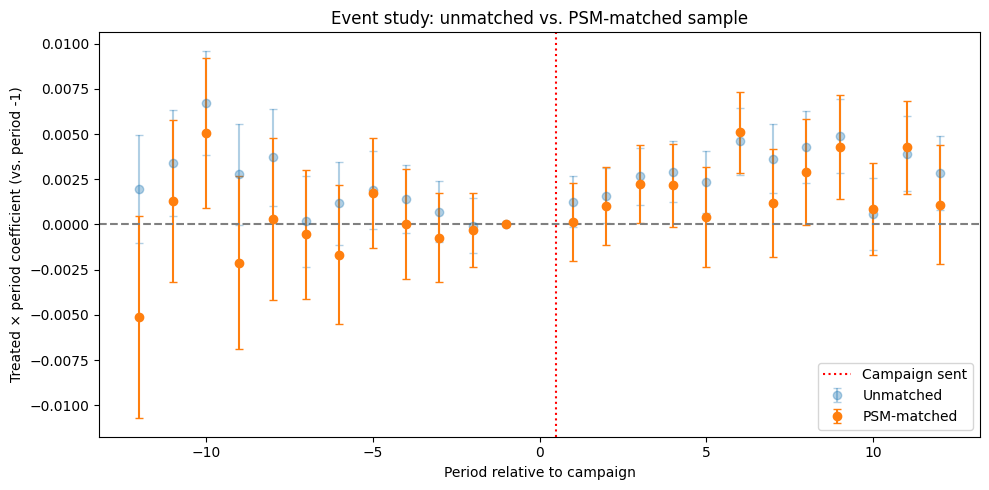

In [39]:
model_es_matched = smf.wls(
    "purchased ~ treated * C(period, Treatment(reference=-1))",
    data=df_matched, weights=df_matched["w"]
).fit(cov_type="cluster", cov_kwds={"groups": df_matched["customer_id"]})

event_coefs_matched = model_es_matched.params.filter(like="treated:C(period")
event_ci_matched = model_es_matched.conf_int().loc[event_coefs_matched.index]

periods_matched = [int(re.search(r"\[T\.(-?\d+)\]", idx).group(1)) for idx in event_coefs_matched.index]

event_study_matched_df = pd.DataFrame({
    "period": periods_matched,
    "coef": event_coefs_matched.values,
    "ci_low": event_ci_matched[0].values,
    "ci_high": event_ci_matched[1].values,
}).sort_values("period")

ref_row_matched = pd.DataFrame({"period": [-1], "coef": [0], "ci_low": [0], "ci_high": [0]})
event_study_matched_df = pd.concat([event_study_matched_df, ref_row_matched]).sort_values("period").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(
    event_study_df["period"], event_study_df["coef"],
    yerr=[event_study_df["coef"] - event_study_df["ci_low"], event_study_df["ci_high"] - event_study_df["coef"]],
    fmt="o", capsize=3, alpha=0.35, label="Unmatched"
)
ax.errorbar(
    event_study_matched_df["period"], event_study_matched_df["coef"],
    yerr=[event_study_matched_df["coef"] - event_study_matched_df["ci_low"],
          event_study_matched_df["ci_high"] - event_study_matched_df["coef"]],
    fmt="o", capsize=3, color="tab:orange", label="PSM-matched"
)
ax.axhline(0, color="grey", linestyle="--")
ax.axvline(0.5, color="red", linestyle=":", label="Campaign sent")
ax.set_xlabel("Period relative to campaign")
ax.set_ylabel("Treated × period coefficient (vs. period -1)")
ax.set_title("Event study: unmatched vs. PSM-matched sample")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Regression adjustment — the independence anchor

**This is the most important section in the revised plan.** Sections 6 and 7 are both DiD variants — they respond to the pre-trend problem, but they still ultimately rest on parallel trends. This one doesn't.

In [54]:
COVARIATES = ["recency_pre", "frequency_pre", "monetary_pre"]

# --- 1. Post-period, customer-window scale: one row per customer ---
# ("did they purchase at all in the post window")
df_post_window = (
    df_combine[df_combine["is_post"] == 1]
    .groupby(["customer_id", "treated"])["purchased"]
    .max()
    .reset_index()
    .merge(df_customers[["customer_id"] + COVARIATES], on="customer_id", how="left")
)

# --- 2. Regression adjustment: condition on the covariates that drove targeting ---
# One row per customer now, so there is nothing left to cluster within --
# HC1 robust SEs are the standard choice for a genuine cross-section.
formula = "purchased ~ treated + " + " + ".join(COVARIATES)

model_ra = smf.ols(formula, data=df_post_window).fit(cov_type="HC1")

ra_estimate = model_ra.params["treated"]
ra_pvalue = model_ra.pvalues["treated"]
ra_ci = model_ra.conf_int().loc["treated"]

print(f"Regression-adjustment estimate: {ra_estimate*100:.2f}pp")
print(f"p-value: {ra_pvalue:.4f}")
print(f"95% CI: [{ra_ci[0]*100:.2f}pp, {ra_ci[1]*100:.2f}pp]")

model_ra.summary()

Regression-adjustment estimate: 1.97pp
p-value: 0.0000
95% CI: [1.43pp, 2.52pp]


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              purchased   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     182.1
Date:                Tue, 25 Aug 2026   Prob (F-statistic):          4.75e-155
Time:                        21:55:13   Log-Likelihood:                -6900.2
No. Observations:               45000   AIC:                         1.381e+04
Df Residuals:                   44995   BIC:                         1.385e+04
Df Model:                           4                                         
Covariance Type:                  HC1                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.0526      0.004     11.877      0.000       0.044       0.061
treated           0.0197      0.003      7.118      0.000       0.014       0.025
recency_pre      -0.0003   2.71e-05    -10.308      0.000      -0.000      -0.000
frequency_pre     0.0129      0.001     19.227      0.000       0.012       0.014
monetary_pre      0.0001   3.13e-05      4.179      0.000    6.94e-05       0.000
==============================================================================
Omnibus:                    24583.733   Durbin-Watson:                   2.008
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           127492.714
Skew:                           2.792   Prob(JB):                         0.00
Kurtosis:                       9.068   Cond. No.                         458.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

## 9. Comparison table

Bring every estimate together in one table: Naive, Shortened Window DiD, PSM + DiD, and Regression Adjustment.

In [59]:
# --- Assemble the comparison -------------------------------------------------
# All estimates are on the SAME scale: probability of purchasing at least once
# during the 12-week post window, per targeted customer. That is what makes
# them directly comparable, and it is the quantity section 13's ROI math needs
# (P(incremental conversion) x margin per conversion).
results = [
    ("Naive (unadjusted)",    "none - selection bias uncontrolled", naive_lift,        None,        None),
    ("PSM + DiD  [headline]", "conditional parallel trends",        psm_estimate,      psm_ci,      psm_pvalue),
    ("Shortened-window DiD",  "parallel trends, weeks -7 on",       trim_did_estimate, trim_did_ci, trim_did_pvalue),
    ("Regression adjustment", "unconfoundedness  <- independent",   ra_estimate,       ra_ci,       ra_pvalue),
]

rows = []
for name, assumption, est, ci, pval in results:
    rows.append({
        "estimator": name,
        "identifying assumption": assumption,
        "incremental conversion (pp)": est * 100,
        "95% CI (pp)": "-" if ci is None else f"[{ci[0]*100:.2f}, {ci[1]*100:.2f}]",
        "p": "-" if pval is None else f"{pval:.4f}",
        "% of naive that is bias": "-" if pval is None else f"{(1 - est / naive_lift) * 100:.0f}%",
    })

comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# --- The agreement region ----------------------------------------------------
# Don't hand a stakeholder the headline point estimate as though it were exact.
# The defensible answer is the band every method's CI is consistent with:
# the highest lower bound to the lowest upper bound.
_cis = [ci for _, _, _, ci, pval in results if ci is not None]
agree_lo = max(ci[0] for ci in _cis)
agree_hi = min(ci[1] for ci in _cis)
_bias = [1 - est / naive_lift for _, _, est, _, pval in results if pval is not None]

print("\n--- Reading this table ---")
print("Use the region where all three methods agree, not a single point estimate:\n")
for name, _, _, ci, pval in results:
    if ci is not None:
        print(f"  {name:26s} [{ci[0]*100:.2f}, {ci[1]*100:.2f}]")
print(f"  {'All three consistent with':26s} [{agree_lo*100:.2f}, {agree_hi*100:.2f}]")

print(f'\nSo: "The campaign drove roughly {agree_lo*100:.1f} to {agree_hi*100:.1f} percentage points of')
print(f'incremental conversion - about {psm_estimate*100:.1f}pp on our preferred specification.')
print(f'Naive reporting says {naive_lift*100:.1f}pp, so {min(_bias)*100:.0f}-{max(_bias)*100:.0f}% of the apparent lift is')
print('selection bias, not campaign effect."')

            estimator             identifying assumption  incremental conversion (pp)  95% CI (pp)      p % of naive that is bias
   Naive (unadjusted) none - selection bias uncontrolled                        2.880            -      -                       -
PSM + DiD  [headline]        conditional parallel trends                        2.541 [1.21, 3.87] 0.0002                     12%
 Shortened-window DiD       parallel trends, weeks -7 on                        2.594 [1.92, 3.27] 0.0000                     10%
Regression adjustment   unconfoundedness  <- independent                        1.975 [1.43, 2.52] 0.0000                     31%

--- Reading this table ---
Use the region where all three methods agree, not a single point estimate:

  PSM + DiD  [headline]      [1.21, 3.87]
  Shortened-window DiD       [1.92, 3.27]
  Regression adjustment      [1.43, 2.52]
  All three consistent with  [1.92, 2.52]

So: "The campaign drove roughly 1.9 to 2.5 percentage points of
incremental c

## 10. Heterogeneity — moderate vs. deep lapse

Split by `lapse_bucket` and rerun your preferred specification in each subgroup. 

In [ ]:
# Pre-specified cut: `lapse_bucket` 

# --- 0. Attach the bucket to the matched customer-window panel ---------------
het = df_matched_window.merge(
    df_customers[["customer_id", "lapse_bucket"]], on="customer_id", how="left"
)

# --- 1. Does matching still balance INSIDE each bucket? ---------------------
# Matching was optimised on the pooled sample; balance overall does not
# guarantee balance within a subgroup. Check before trusting the split.
matched_customers = df_customers[df_customers["customer_id"].isin(weight_map.index)].copy()
matched_customers["w"] = matched_customers["customer_id"].map(weight_map)

print("=== Balance within each bucket (matched sample) ===")
for bucket, sub in matched_customers.groupby("lapse_bucket"):
    bal = balance_report(sub, weight_col="w")
    n_t = int((sub["treated"] == 1).sum())
    n_c = int((sub["treated"] == 0).sum())
    flag = "OK" if bal["balanced"].all() else "FAILS"
    print(f"{bucket:9s} {n_t:6,} treated / {n_c:6,} distinct controls  [{flag}]  "
          + "  ".join(f"{r.covariate.split('_')[0]}={r.smd:+.3f}" for r in bal.itertuples()))

# --- 2. Subgroup estimates, headline spec (PSM + DiD) ----------------------
print("\n=== PSM + DiD by lapse bucket ===")
subgroup_rows = []
for bucket, sub in het.groupby("lapse_bucket"):
    m = smf.wls("purchased ~ treated * is_post", data=sub, weights=sub["w"]).fit(
        cov_type="cluster", cov_kwds={"groups": sub["customer_id"]})
    est = m.params["treated:is_post"]
    ci = m.conf_int().loc["treated:is_post"]
    subgroup_rows.append({
        "lapse_bucket": bucket,
        "incremental conversion (pp)": est * 100,
        "95% CI (pp)": f"[{ci[0]*100:.2f}, {ci[1]*100:.2f}]",
        "CI width (pp)": (ci[1] - ci[0]) * 100,
        "p": f"{m.pvalues['treated:is_post']:.4f}",
    })
subgroup = pd.DataFrame(subgroup_rows)
print(subgroup.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# --- 3. Do the buckets actually DIFFER? ------------------------------------
# Comparing two subgroup CIs by eye is the wrong test -- overlapping intervals
# do not imply "no difference". The triple interaction tests it directly.
m_int = smf.wls(
    "purchased ~ treated * is_post * C(lapse_bucket, Treatment(reference='moderate'))",
    data=het, weights=het["w"],
).fit(cov_type="cluster", cov_kwds={"groups": het["customer_id"]})

term = [t for t in m_int.params.index if t.startswith("treated:is_post:")][0]
diff, diff_p = m_int.params[term], m_int.pvalues[term]
diff_ci = m_int.conf_int().loc[term]

print(f"\n=== Difference in effect: deep - moderate (triple interaction) ===")
print(f"{diff*100:+.2f}pp   95% CI [{diff_ci[0]*100:+.2f}, {diff_ci[1]*100:+.2f}]   p = {diff_p:.4f}")
print("SIGNIFICANT: the buckets genuinely differ." if diff_p < 0.05 else
      "NOT significant: cannot distinguish the buckets at conventional levels.")

# --- 4. Cross-check with regression adjustment ------------------------------
# This subgroup result is about to drive a targeting recommendation -- a more
# consequential claim than the pooled average. Corroborate it with the one
# estimator that does not rest on parallel trends.
print("\n=== Cross-check: regression adjustment by bucket ===")
ra_post = df_post_window.merge(
    df_customers[["customer_id", "lapse_bucket"]], on="customer_id", how="left"
)
for bucket, sub in ra_post.groupby("lapse_bucket"):
    m = smf.ols("purchased ~ treated + " + " + ".join(COVARIATES), data=sub).fit(cov_type="HC1")
    ci = m.conf_int().loc["treated"]
    print(f"{bucket:9s} {m.params['treated']*100:6.2f}pp   "
          f"[{ci[0]*100:.2f}, {ci[1]*100:.2f}]   p = {m.pvalues['treated']:.4f}")

=== Balance within each bucket (matched sample) ===
deep       7,432 treated /  2,627 distinct controls  [OK]  recency=-0.051  frequency=+0.022  monetary=+0.059
moderate  17,084 treated /  8,558 distinct controls  [OK]  recency=-0.005  frequency=+0.010  monetary=+0.008

=== PSM + DiD by lapse bucket ===
lapse_bucket  incremental conversion (pp)   95% CI (pp)  CI width (pp)      p
        deep                       -1.092 [-3.38, 1.20]          4.577 0.3497
    moderate                        4.136  [2.51, 5.76]          3.249 0.0000

=== Difference in effect: deep - moderate (triple interaction) ===
-5.23pp   95% CI [-8.03, -2.42]   p = 0.0003
SIGNIFICANT: the buckets genuinely differ.

=== Cross-check: regression adjustment by bucket ===
deep       -0.12pp   [-1.07, 0.83]   p = 0.8082
moderate    2.64pp   [1.99, 3.29]   p = 0.0000


## 11. Findings

### The headline

**The win-back campaign works, but it is worth about 12% less than the dashboard says — and essentially all of its value comes from one half of the target list.**

| | incremental conversion | 95% CI |
|---|---|---|
| Naive (dashboard) comparison | 2.88pp | — |
| **PSM + DiD (preferred)** | **2.54pp** | [1.21, 3.87] |
| Shortened-window DiD | 2.59pp | [1.92, 3.27] |
| Regression adjustment | 1.98pp | [1.43, 2.52] |
| **All three consistent with** | **1.9 – 2.5pp** | |

Every method agrees the effect is real, positive, and smaller than the naive figure. Between 10% and 31% of the apparent lift is selection bias — customers who were coming back anyway, credited to an email that did not cause it.

The credibility here does not rest on any single estimate. Shortened-window DiD is a **robustness check** — same identifying assumption, different handling of the problematic pre-period. Regression adjustment is **triangulation** — it rests on unconfoundedness rather than parallel trends, so it can fail independently. Its agreement is the part that matters.

### The finding that should change what the team does

Splitting by lapse depth reverses the picture for half the list:

| segment | targeted | incremental effect | 95% CI | p |
|---|---|---|---|---|
| Moderate (60–119d) | 17,084 | **+4.14pp** | [2.51, 5.76] | <0.0001 |
| Deep (≥120d) | 7,432 | **−1.09pp** | [−3.38, 1.20] | 0.35 |
| **Difference** | | **−5.23pp** | [−8.03, −2.42] | **0.0003** |

The gap is statistically real, not a subgroup fishing artifact — `lapse_bucket` was pre-specified on theoretical grounds, and the difference is confirmed by a triple-interaction test rather than by eyeballing two intervals. Regression adjustment reproduces the pattern independently (moderate +2.64pp, deep −0.12pp), which matters because a targeting recommendation is a more consequential claim than an average effect.

**This is Ascarza's "retention futility" in the data.** A dashboard shows deep-lapse customers converting at 6.19% versus 5.79% for untargeted ones — a positive-looking 0.40pp lift. Incrementally it is indistinguishable from zero. Those customers were cycling back on their own; the email is taking credit for a trajectory it did not change.

**Precision matters for how this is stated.** Deep-lapse is *"no detectable effect, and we can rule out anything above roughly 1.2pp"* — not *"the effect is zero."* Regression adjustment's tighter interval ([−1.07, 0.83]) sharpens that ceiling considerably, which is what makes the conclusion actionable rather than merely inconclusive.

---

### Assumptions and limitations

**Parallel trends failed the first test, and that shaped the entire analysis.** The plain DiD placebo returned −1.22pp (p=0.0008) and the joint pre-trends F-test rejected at p=0.0002. Rather than proceed on an assumption the data contradicted, the analysis was rebuilt around specifications that respond to it.

**What fixed it, and how we know.** Matching on RFM drove covariate imbalance from SMD ≈ 0.34 to ≈ 0.02, and the matched-sample diagnostics cleared: placebo 0.04pp (p=0.95), joint F-test p=0.24, pre-period drift falling from −0.038pp/wk to +0.006pp/wk. Note the *individual* event-study coefficients did not shrink much — with a 1.5% weekly purchase rate the per-period estimates carry ±0.19pp of error, so scatter is expected. Parallel trends is a claim about systematic drift, not about every period sitting at zero, and it is the drift that disappeared.

**Assumptions the headline still rests on:**
- **Conditional parallel trends.** Tested and passed, but passing a placebo means *failing to detect* a violation, not proving none exists.
- **Unconfoundedness** (for the regression-adjustment leg). Untestable in principle. Credible here because targeting is a rule-based CRM process on observable RFM, but any unmeasured input to that rule — email engagement history, tenure, channel preference — would bias it. DiD differences such factors away if they are time-invariant; regression adjustment cannot.
- **No anticipation effects.** Customers did not change behaviour before receiving the email.
- **No spillovers.** Untargeted customers were unaffected by the campaign.

**Known weaknesses:**
- **The preferred estimate is the least precise.** PSM+DiD's CI is [1.21, 3.87], nearly triple regression adjustment's width — the price of matching with replacement, which reuses 11,185 distinct controls to serve 24,516 treated customers. It is preferred for diagnostic strength, not precision.
- **Regression adjustment is systematically lower** (1.98pp vs 2.54/2.59pp). The two DiD variants share an assumption, so their agreement was never independent evidence. Effectively there are two estimates — ~2.5pp from trend-based methods, ~2.0pp from the unconfoundedness-based one — and this analysis cannot fully adjudicate between them.
- **The deep-lapse subgroup is thin.** 7,432 treated matched against only 2,627 distinct controls, so its wide interval reflects limited power as much as a genuine null.
- **Linear probability models throughout.** For the saturated DiD specifications this imposes no functional form. For regression adjustment, with continuous covariates, it does — 0.54% of fitted values fall below zero. Good covariate overlap keeps the resulting bias small, but a binned-covariate robustness check was not run.

**Not implemented, and why:** formal sensitivity analysis (Rambachan & Roth 2023) requires the R-only `HonestDiD` package; synthetic DiD is built for few-units × many-periods panels, the opposite of this 45,000 × 24 shape. Both are cited as the rigorous treatments rather than approximated badly.

**Simulated data.** The dataset is simulated, not company data. Base rates were chosen as plausible values rather than drawn from published benchmarks. The methodology transfers; the specific magnitudes should not be quoted as industry figures.

**What a randomized holdout would have given us.** All of the above is second-best identification. A randomized holdout — withholding the email from a random slice of the eligible list — would deliver the same estimate with no parallel-trends assumption, no unconfoundedness assumption, and no triangulation required. Lewis & Reiley (2014) and Gordon et al. (2018) both show observational estimators can miss experimental benchmarks even with rich covariates. The recommendation below reflects that gap.

## 12. Marketing recommendations

*Cost assumption: sends are treated as costless. This is deliberately the most favourable case for the campaign — if a recommendation to stop sending survives even at zero cost, it is robust to any cost assumption above zero.*

### What the campaign actually delivered

Across 24,516 emails, roughly **620 incremental conversions** — about 710 generated in the moderate-lapse segment, offset by a statistically insignificant negative in deep-lapse. At zero cost, the campaign is unambiguously worth running. **Keep it.**

That is the easy part. The composition is where the decision lives.

### 1. Stop treating deep-lapse as a win-back audience

30% of the list (7,432 customers) is deeply lapsed, and that group produced no detectable incremental conversions. On the dashboard it looks fine — 6.19% conversion versus 5.79% untargeted — but nearly all of that is customers who were returning regardless.

**At zero monetary cost, the argument to stop is not financial.** It is that email is never actually free:

- **Deliverability.** Sending to chronically unengaged addresses is precisely what inbox providers use to classify a sender as spam. That damage lands on *every* campaign, including the moderate-lapse sends that do work.
- **List attrition.** Every send to someone with no interest risks an unsubscribe, permanently removing a customer who may re-engage later through another channel.
- **Measurement distortion.** As long as deep-lapse stays in the campaign, blended reporting mixes a 4pp-effect segment with a 0pp-effect one and produces a number that describes neither.

**Recommendation:** remove deep-lapse from the standing win-back flow. Retain a small holdout there for ongoing measurement rather than dropping the segment blind.

### 2. Expand into the moderate-lapse customers who were never targeted

This is the largest opportunity in the analysis, and it is invisible in the naive framing.

**16,719 moderately-lapsed customers did not receive the email.** They sit inside the same covariate range as the ones who did — matching found a within-caliper control for 100% of treated customers, so this is interpolation, not extrapolation into unfamiliar territory. At the measured 4.14pp incremental effect, reaching them implies **roughly 690 additional incremental conversions** — approximately doubling what the campaign produced, at zero incremental cost.

**Recommendation:** extend the campaign to untargeted moderate-lapse customers. **Roll it out as a randomized test, not a full send** — which also solves the measurement problem below.

### 3. The targeting logic is backwards, and that is the transferable lesson

The current rule prioritises customers by *how lapsed they are*. The data says incremental effect moves in the opposite direction: the further gone a customer is, the less an email changes their behaviour.

This is the Farahat & Bailey caution in a different guise. Their warning was about targeting customers who would convert anyway; here it is targeting customers who **will not convert regardless**. Both produce naive metrics that look reasonable and incremental value near zero. The common failure is optimising a targeting rule against *observed conversion* rather than *incremental conversion* — and those rank segments in genuinely different orders.

**Recommendation:** re-specify the targeting rule around estimated incremental response rather than lapse depth. Concretely: rank by predicted uplift, not by recency score.

### 4. Run a holdout — the single highest-value next step

Every number above rests on assumptions that cannot be fully verified: parallel trends passed a placebo but was violated in the raw data, and unconfoundedness is untestable in principle. The two estimator families still disagree by about 0.5pp (2.5pp vs 2.0pp), and this analysis cannot adjudicate it.

A randomized holdout resolves all of it. **The expansion in recommendation 2 is the natural vehicle** — withhold the email from a random 10–20% of the newly-targeted moderate-lapse group. That yields an unbiased benchmark, costs nothing beyond forgone sends to a small slice, and validates or corrects every estimate here.

**Recommendation:** make the expansion a randomized rollout. There is no reason to run it any other way.

### What would change these recommendations

| if this were true | what changes |
|---|---|
| Sends carry meaningful cost (agency fees, SMS, direct mail) | Recommendation 1 strengthens sharply — deep-lapse becomes an active loss, not merely a null |
| Deep-lapse customers carry much higher margin when they do convert | Worth re-running heterogeneity on revenue rather than conversion; a small effect on high-value customers could still pay |
| The true effect sits at regression adjustment's 1.98pp, not 2.54pp | Total conversions fall ~20%; at zero cost every recommendation still holds |
| Deep-lapse's true effect sits at the top of its interval (+1.2pp) | Recommendation 1 weakens to "deprioritise" rather than "remove" — this is exactly what the holdout would settle |

**The recommendations are stable across the plausible range of estimates.** That is worth more than the point estimate itself: the decision does not hinge on getting the number exactly right, only on the segment ordering — which two independent estimators agree on.